In [1]:
## Historical VaR (95%) — 5th percentile of daily return distribution. CVaR = mean of returns below VaR threshold. Compute for all 40 schemes.

In [2]:
import pandas as pd
import numpy as np

In [3]:
nav = pd.read_csv("C:/MutualfundProject/data/raw/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
nav['date'] = pd.to_datetime(nav['date'])

In [6]:
nav['date'].min(), nav['date'].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [7]:
nav = nav.sort_values(['amfi_code', 'date'])

In [8]:
nav[nav['amfi_code'] == nav['amfi_code'].iloc[0]].head(10)

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639
5755,100016,2022-01-10,510.7136
5756,100016,2022-01-11,513.5542
5757,100016,2022-01-12,512.3195
5758,100016,2022-01-13,510.2445
5759,100016,2022-01-14,514.3636


In [9]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [10]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [11]:
returns = nav.dropna(subset=['daily_return']).copy()

In [12]:
returns['daily_return'].isna().sum()

np.int64(0)

In [13]:
returns['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [14]:
returns.sort_values('daily_return').head(10)

,amfi_code,date,nav,daily_return
19674,118634,2022-06-24,67.2534,-0.058102
33667,101207,2023-03-22,56.8326,-0.051847
19852,118634,2023-03-01,113.5801,-0.050335
45312,149324,2023-10-11,111.8155,-0.048870
34310,101207,2025-09-08,62.3200,-0.048634
31304,119095,2022-12-23,73.9946,-0.048367
20233,118634,2024-08-15,114.5168,-0.048305
31807,119095,2024-11-27,78.1317,-0.046524
4198,119599,2024-11-14,112.8996,-0.045429
9770,125498,2024-03-11,131.4556,-0.045218


In [15]:
returns.sort_values('daily_return', ascending=False).head(10)

,amfi_code,date,nav,daily_return
2895,119598,2024-04-15,189.0742,0.064713
20126,118634,2024-03-19,110.5401,0.059304
33957,101207,2024-05-01,65.5882,0.054851
3716,119599,2023-01-10,153.2221,0.053320
3982,119599,2024-01-17,136.8239,0.051811
2305,119598,2022-01-10,96.0964,0.051113
2521,119598,2022-11-08,123.9704,0.049051
45082,149324,2022-11-23,98.3696,0.048490
2506,119598,2022-10-18,122.2757,0.048454
3241,119598,2025-08-12,200.8460,0.047123


In [16]:
var_95 = returns['daily_return'].quantile(0.05)

In [17]:
var_results = (
    returns.groupby('amfi_code')['daily_return']
           .quantile(0.05)
           .reset_index()
)

In [18]:
var_results = var_results.rename(
    columns={'daily_return': 'VaR_95'}
)

In [19]:
var_results.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [20]:
def calculate_var_cvar(group):
    
    var = group['daily_return'].quantile(0.05)
    
    cvar = group.loc[
        group['daily_return'] <= var,
        'daily_return'
    ].mean()
    
    return pd.Series({
        'VaR_95': var,
        'CVaR_95': cvar
    })

In [21]:
risk_results = (
    returns
    .groupby('amfi_code')
    .apply(calculate_var_cvar)
    .reset_index()
)

In [22]:
risk_results.head(10)

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459
5,101208,-0.000269,-0.000422
6,102885,-0.012613,-0.015490
7,102886,-0.019220,-0.023251
8,102887,-0.015232,-0.019411
9,118632,-0.013954,-0.017619


In [23]:
risk_results['VaR_95_pct'] = risk_results['VaR_95'] * 100
risk_results['CVaR_95_pct'] = risk_results['CVaR_95'] * 100

In [24]:
risk_results['amfi_code'].nunique()

40

In [25]:
returns['amfi_code'].nunique()

40

In [26]:
all_schemes = set(nav['amfi_code'].unique())
risk_schemes = set(risk_results['amfi_code'].unique())

missing_schemes = all_schemes - risk_schemes

missing_schemes

set()

In [27]:
fund_master = pd.read_csv("C:/MutualFundProject/data/raw/01_fund_master.csv")

In [28]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [29]:
risk_results = risk_results.merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category']],
    on='amfi_code',
    how='left'
)

In [30]:
risk_results.head()

,amfi_code,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct,scheme_name,fund_house,category
0,100016,-0.014364,-0.018060,-1.436364,-1.806021,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100025,-0.003793,-0.004994,-0.379325,-0.499376,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt
2,100033,-0.019034,-0.023456,-1.903354,-2.345576,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
3,101206,-0.013282,-0.017439,-1.328166,-1.743943,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
4,101207,-0.026021,-0.032459,-2.602125,-3.245906,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity


In [31]:
risk_results.sort_values(
    'VaR_95_pct'
).head(10)

,amfi_code,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct,scheme_name,fund_house,category
22,119599,-0.026859,-0.032384,-2.685944,-3.238412,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
17,119095,-0.026188,-0.031667,-2.618842,-3.166729,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity
4,101207,-0.026021,-0.032459,-2.602125,-3.245906,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
11,118634,-0.025438,-0.032304,-2.543811,-3.230407,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity
21,119598,-0.024507,-0.030595,-2.450705,-3.059526,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
39,149324,-0.023483,-0.031036,-2.348307,-3.103625,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
7,102886,-0.019220,-0.023251,-1.922028,-2.325086,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
2,100033,-0.019034,-0.023456,-1.903354,-2.345576,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
25,120505,-0.018892,-0.024342,-1.889179,-2.434207,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
16,119094,-0.018480,-0.024260,-1.848028,-2.426006,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity


In [32]:
final_risk_table = risk_results[
    [
        'amfi_code',
        'scheme_name',
        'fund_house',
        'category',
        'VaR_95_pct',
        'CVaR_95_pct'
    ]
].sort_values('VaR_95_pct')

In [33]:
final_risk_table

,amfi_code,scheme_name,fund_house,category,VaR_95_pct,CVaR_95_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-2.685944,-3.238412
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-2.618842,-3.166729
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-2.602125,-3.245906
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-2.543811,-3.230407
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-2.450705,-3.059526
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-2.348307,-3.103625
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-1.922028,-2.325086
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-1.903354,-2.345576
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,-1.889179,-2.434207
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,-1.848028,-2.426006


In [34]:
final_risk_table['VaR_95_pct'] = (
    final_risk_table['VaR_95_pct'].round(2)
)

final_risk_table['CVaR_95_pct'] = (
    final_risk_table['CVaR_95_pct'].round(2)
)

In [36]:
final_risk_table.to_csv(
    "C:/MutualFundProject/data/processed/Advanced_Analytics_CSV_file/01_historical_var_cvar_40_schemes.csv",
    index=False
)

In [37]:
## Rolling 90-day Sharpe — returns.rolling(90).mean() / returns.rolling(90).std() × √252. Plot over time for 5 key funds.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("C:/MutualFundProject/data/raw/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [39]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [40]:
nav['date'] = pd.to_datetime(nav['date'])

In [41]:
nav = nav.sort_values(['amfi_code', 'date'])

In [42]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [43]:
nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [44]:
returns = nav.dropna(subset = ['daily_return']).copy()

In [45]:
returns['rolling_mean_90'] = (
    returns.groupby('amfi_code')['daily_return']
           .transform(lambda x: x.rolling(90).mean())
)

returns['rolling_std_90'] = (
    returns.groupby('amfi_code')['daily_return']
           .transform(lambda x: x.rolling(90).std())
)

In [46]:
returns['rolling_sharpe_90'] = (
    returns['rolling_mean_90']
    / returns['rolling_std_90']
    * np.sqrt(252)
)

In [47]:
returns[
    returns['amfi_code'] == returns['amfi_code'].iloc[0]
][['date', 'daily_return', 'rolling_sharpe_90']].head(95)

,date,daily_return,rolling_sharpe_90
5751,2022-01-04,-0.010306,NaN
5752,2022-01-05,0.012865,NaN
5753,2022-01-06,-0.011377,NaN
5754,2022-01-07,-0.001210,NaN
5755,2022-01-10,-0.008639,NaN
...,...,...,...
5841,2022-05-10,-0.009987,-0.058880
5842,2022-05-11,-0.012576,-0.532521
5843,2022-05-12,-0.018051,-0.649005
5844,2022-05-13,0.006898,-0.498278


In [48]:
key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

In [49]:
rolling_sharpe_5 = returns[
    returns['amfi_code'].isin(key_funds)
].copy()

In [50]:
rolling_sharpe_5['amfi_code'].nunique()

5

In [51]:
fund_master = pd.read_csv("C:/Mutualfundproject/data/raw/01_fund_master.csv")

fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [52]:
rolling_sharpe_5 = rolling_sharpe_5.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [53]:
rolling_sharpe_5[
    ['date', 'amfi_code', 'scheme_name', 'rolling_sharpe_90']
].head()

,date,amfi_code,scheme_name,rolling_sharpe_90
0,2022-01-04,118632,Nippon India Large Cap Fund - Regular - Growth,NaN
1,2022-01-05,118632,Nippon India Large Cap Fund - Regular - Growth,NaN
2,2022-01-06,118632,Nippon India Large Cap Fund - Regular - Growth,NaN
3,2022-01-07,118632,Nippon India Large Cap Fund - Regular - Growth,NaN
4,2022-01-10,118632,Nippon India Large Cap Fund - Regular - Growth,NaN


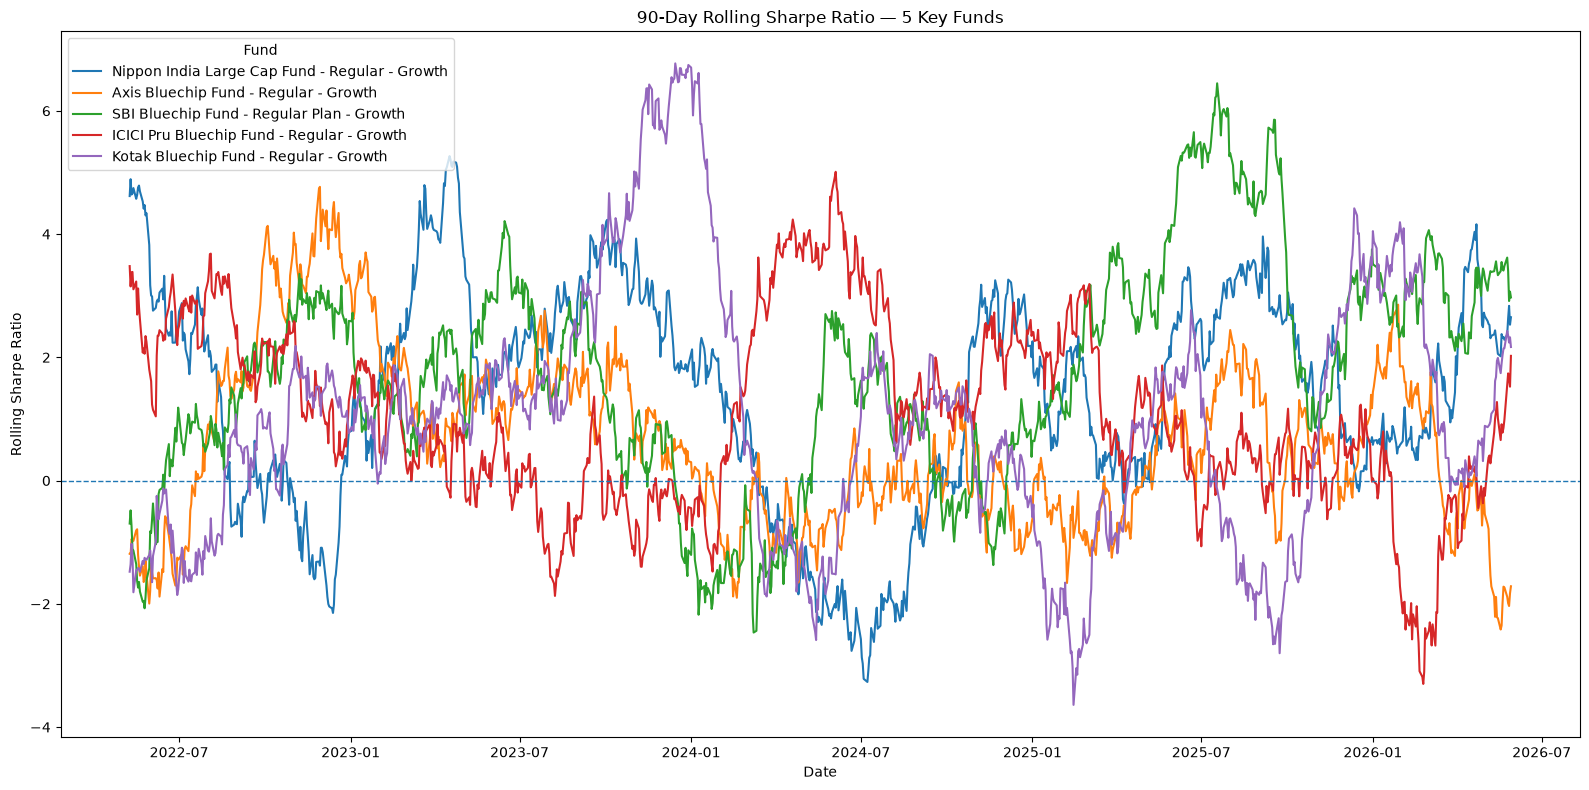

In [54]:
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=rolling_sharpe_5,
    x='date',
    y='rolling_sharpe_90',
    hue='scheme_name'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title('90-Day Rolling Sharpe Ratio — 5 Key Funds')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend(title='Fund')
plt.tight_layout()

plt.show()

In [55]:
fund_summary = (
    rolling_sharpe_5
    .groupby('scheme_name')['rolling_sharpe_90']
    .agg(
        average_rolling_sharpe='mean',
        maximum_rolling_sharpe='max',
        minimum_rolling_sharpe='min'
    )
    .reset_index()
)

In [56]:
fund_summary.sort_values(
    'average_rolling_sharpe',
    ascending=False
)

,scheme_name,average_rolling_sharpe,maximum_rolling_sharpe,minimum_rolling_sharpe
4,SBI Bluechip Fund - Regular Plan - Growth,1.727788,6.446039,-2.465994
3,Nippon India Large Cap Fund - Regular - Growth,1.402335,5.265426,-3.267884
1,ICICI Pru Bluechip Fund - Regular - Growth,1.040287,5.010124,-3.299569
2,Kotak Bluechip Fund - Regular - Growth,0.971429,6.769155,-3.639571
0,Axis Bluechip Fund - Regular - Growth,0.617369,4.766055,-2.416716


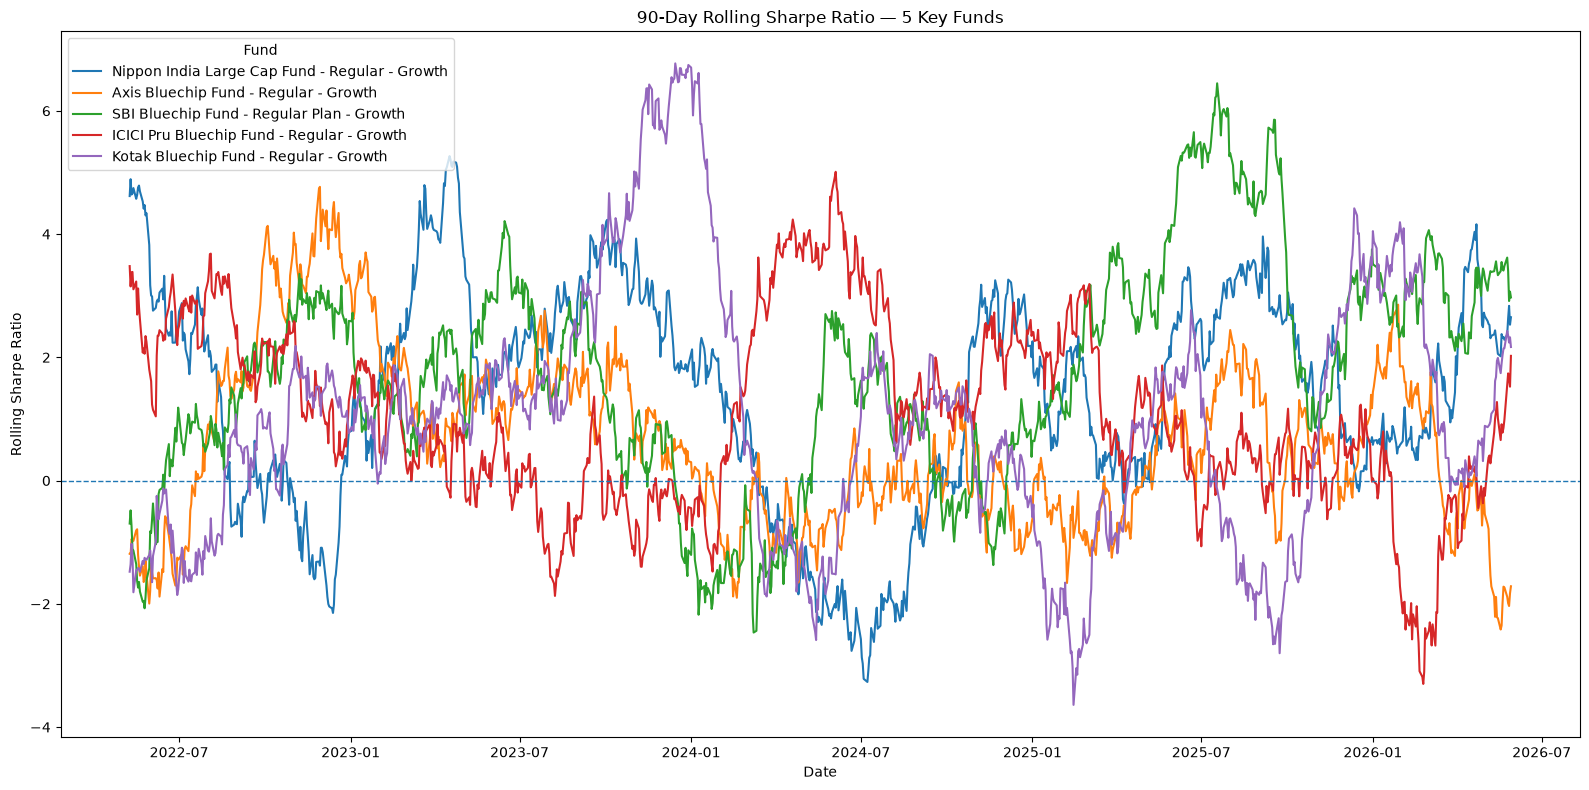

In [57]:
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=rolling_sharpe_5,
    x='date',
    y='rolling_sharpe_90',
    hue='scheme_name'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title('90-Day Rolling Sharpe Ratio — 5 Key Funds')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend(title='Fund')
plt.tight_layout()

plt.savefig(
    "C:/MutualFundProject/data/processed/Advanced_Analytics_CSV_file/reports/rolling_90_day_sharpe_5_funds.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [58]:
returns.rolling(90)

Rolling [window=90,center=False,method=single]

In [59]:
returns.groupby('amfi_code')

In [60]:
## Investor cohort analysis — group by first transaction year. Compute avg SIP amount, total invested, and top fund preference per cohort.

In [61]:
import pandas as pd
import numpy as np

transactions = pd.read_csv(
    "C:/MutualFundproject/data/raw/08_investor_transactions.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [62]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [63]:
transactions.shape
transactions.dtypes

investor_id               str
transaction_date          str
amfi_code               int64
transaction_type          str
amount_inr              int64
state                     str
city                      str
city_tier                 str
age_group                 str
gender                    str
annual_income_lakh    float64
payment_mode              str
kyc_status                str
dtype: object

In [64]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [65]:
transactions['transaction_date'].min()
transactions['transaction_date'].max()

Timestamp('2025-05-30 00:00:00')

In [66]:
first_transaction = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

In [67]:
first_transaction = first_transaction.rename(
    columns={
        'transaction_date': 'first_transaction_date'
    }
)

In [68]:
first_transaction.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [69]:
first_transaction['cohort_year'] = (
    first_transaction['first_transaction_date']
    .dt.year
)

In [70]:
transactions = transactions.merge(
    first_transaction[
        ['investor_id', 'cohort_year']
    ],
    on='investor_id',
    how='left'
)

In [71]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [72]:
sip_transactions = transactions[
    transactions['transaction_type'].str.upper() == 'SIP'
].copy()

In [73]:
avg_sip = (
    sip_transactions
    .groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index()
)

In [74]:
avg_sip = avg_sip.rename(
    columns={
        'amount_inr': 'avg_sip_amount'
    }
)

In [75]:
avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [76]:
investment_transactions = transactions[
    transactions['transaction_type'].str.upper().isin(
        ['SIP', 'LUMPSUM']
    )
].copy()

In [77]:
total_invested = (
    investment_transactions
    .groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index()
)

In [78]:
total_invested = total_invested.rename(
    columns={
        'amount_inr': 'total_invested'
    }
)

In [79]:
fund_preference = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='transaction_count')
)

In [80]:
fund_preference.head()

,cohort_year,amfi_code,transaction_count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844


In [81]:
fund_preference = fund_preference.sort_values(
    ['cohort_year', 'transaction_count'],
    ascending=[True, False]
)

In [82]:
top_fund = (
    fund_preference
    .groupby('cohort_year')
    .first()
    .reset_index()
)

In [83]:
top_fund

,cohort_year,amfi_code,transaction_count
0,2024,148568,874
1,2025,119599,12


In [84]:
fund_master = pd.read_csv(
    "C:/MutualFundProject/data/raw/01_fund_master.csv"
)

In [85]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [86]:
top_fund = top_fund.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [87]:
top_fund

,cohort_year,amfi_code,transaction_count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [88]:
cohort_analysis = avg_sip.merge(
    total_invested,
    on='cohort_year',
    how='outer'
)

In [89]:
cohort_analysis = cohort_analysis.merge(
    top_fund[
        [
            'cohort_year',
            'amfi_code',
            'scheme_name',
            'transaction_count'
        ]
    ],
    on='cohort_year',
    how='left'
)

In [90]:
cohort_analysis

,cohort_year,avg_sip_amount,total_invested,amfi_code,scheme_name,transaction_count
0,2024,10996.885825,2258062304,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,119599,SBI Small Cap Fund - Direct Plan - Growth,12


In [91]:
cohort_analysis['avg_sip_amount'] = (
    cohort_analysis['avg_sip_amount'].round(2)
)

cohort_analysis['total_invested'] = (
    cohort_analysis['total_invested'].round(2)
)

In [92]:
cohort_analysis.to_csv(
    "C:/MutualFundproject/data/processed/Advanced_Analytics_CSV_file/03_investor_cohort_analysis.csv",
    index=False
)

In [93]:
## SIP continuity analysis — for investors with 6+ SIP transactions, compute avg gap between dates. Flag investors with gap > 35 days as "at-risk".  

In [94]:
import pandas as pd
import numpy as np

transactions = pd.read_csv(
    "C:/MutualFundProject/data/raw/08_investor_transactions.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [95]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [96]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [97]:
transactions['transaction_date'].min()
transactions['transaction_date'].max()

Timestamp('2025-05-30 00:00:00')

In [98]:
sip = transactions[
    transactions['transaction_type'].str.upper() == 'SIP'
].copy()

In [99]:
sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [100]:
sip.shape

(19716, 13)

In [101]:
sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

In [102]:
sip_count = (
    sip.groupby('investor_id')
       .size()
       .reset_index(name='sip_count')
)

In [103]:
sip_count.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [104]:
eligible_investors = sip_count[
    sip_count['sip_count'] >= 6
]['investor_id']

In [105]:
sip_eligible = sip[
    sip['investor_id'].isin(eligible_investors)
].copy()

In [106]:
sip_eligible['investor_id'].nunique()

1362

In [107]:
sip_eligible['gap_days'] = (
    sip_eligible
    .groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

In [108]:
sip_eligible[
    ['investor_id', 'transaction_date', 'gap_days']
].head(15)

,investor_id,transaction_date,gap_days
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0
12003,INV000004,2024-07-07,59.0
28749,INV000004,2025-03-29,265.0
31897,INV000004,2025-05-17,49.0
9329,INV000008,2024-05-27,NaN
11113,INV000008,2024-06-23,27.0
21549,INV000008,2024-12-05,165.0
24389,INV000008,2025-01-18,44.0


In [109]:
investor_gap = (
    sip_eligible
    .groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap_days=('gap_days', 'mean'),
        max_gap_days=('gap_days', 'max')
    )
    .reset_index()
)

In [110]:
investor_gap.head()

,investor_id,sip_count,avg_gap_days,max_gap_days
0,INV000004,6,85.400000,265.0
1,INV000008,6,70.400000,165.0
2,INV000010,6,64.800000,139.0
3,INV000011,7,40.166667,125.0
4,INV000012,8,57.000000,132.0


In [111]:
investor_gap['risk_status'] = np.where(
    investor_gap['avg_gap_days'] > 35,
    'at-risk',
    'active'
)

In [112]:
max_gap = (
    sip_eligible
    .groupby('investor_id')['gap_days']
    .max()
    .reset_index(name='max_gap_days')
)

In [113]:
investor_gap['risk_status'] = np.where(
    investor_gap['max_gap_days'] > 35,
    'at-risk',
    'active'
)

In [114]:
risk_gaps = (
    sip_eligible
    .assign(
        risky_gap=lambda x: x['gap_days'] > 35
    )
    .groupby('investor_id')['risky_gap']
    .sum()
    .reset_index(name='risky_gap_count')
)

In [115]:
investor_gap = investor_gap.merge(
    risk_gaps,
    on='investor_id',
    how='left'
)

In [116]:
investor_gap['avg_gap_days'] = (
    investor_gap['avg_gap_days'].round(2)
)


In [117]:
display(investor_gap)

,investor_id,sip_count,avg_gap_days,max_gap_days,risk_status,risky_gap_count
0,INV000004,6,85.40,265.0,at-risk,3
1,INV000008,6,70.40,165.0,at-risk,3
2,INV000010,6,64.80,139.0,at-risk,3
3,INV000011,7,40.17,125.0,at-risk,3
4,INV000012,8,57.00,132.0,at-risk,5
...,...,...,...,...,...,...
1357,INV004984,7,75.33,177.0,at-risk,3
1358,INV004986,7,81.33,185.0,at-risk,3
1359,INV004992,7,81.50,176.0,at-risk,5
1360,INV004996,10,46.33,104.0,at-risk,4


In [118]:
status_summary = (
    investor_gap['risk_status']
    .value_counts()
    .reset_index()
)

status_summary.columns = [
    'risk_status',
    'investor_count'
]

status_summary

,risk_status,investor_count
0,at-risk,1361
1,active,1


In [119]:
status_summary['percentage'] = (
    status_summary['investor_count']
    / status_summary['investor_count'].sum()
    * 100
)

status_summary['percentage'] = (
    status_summary['percentage'].round(2)
)

status_summary

,risk_status,investor_count,percentage
0,at-risk,1361,99.93
1,active,1,0.07


In [120]:
investor_gap.sort_values(
    'max_gap_days',
    ascending=False
).head(20)

,investor_id,sip_count,avg_gap_days,max_gap_days,risk_status,risky_gap_count
256,INV000862,6,91.20,372.0,at-risk,2
26,INV000082,7,83.67,351.0,at-risk,3
798,INV002912,6,97.00,342.0,at-risk,3
536,INV002001,6,84.80,335.0,at-risk,2
956,INV003484,6,73.80,333.0,at-risk,1
882,INV003223,8,67.71,331.0,at-risk,2
578,INV002177,7,73.00,330.0,at-risk,2
311,INV001070,6,97.00,329.0,at-risk,3
1018,INV003686,6,96.60,328.0,at-risk,3
183,INV000608,6,100.20,324.0,at-risk,3


In [121]:
investor_gap.sort_values(
    'risky_gap_count',
    ascending=False
).head(20)

,investor_id,sip_count,avg_gap_days,max_gap_days,risk_status,risky_gap_count
117,INV000399,10,49.56,68.0,at-risk,7
817,INV003003,9,58.25,100.0,at-risk,7
1334,INV004889,7,70.67,159.0,at-risk,6
986,INV003598,8,68.00,114.0,at-risk,6
1163,INV004203,8,66.57,113.0,at-risk,6
199,INV000657,8,64.71,106.0,at-risk,6
1115,INV004009,8,62.29,87.0,at-risk,6
194,INV000642,9,53.50,139.0,at-risk,6
1135,INV004116,10,54.89,117.0,at-risk,6
306,INV001060,9,53.38,89.0,at-risk,6


In [122]:
investor_gap.to_csv(
    "C:/MutualFundProject/data/processed/Advanced_Analytics_CSV_file/04_sip_continuity_analysis.csv",
    index=False
)

In [123]:
## Simple fund recommender — input: risk appetite (Low / Moderate / High). Output: top 3 funds by Sharpe ratio within matching risk_grade.
## Print recommendation table.

In [124]:
import pandas as pd
import numpy as np

performance = pd.read_csv(
    "C:/MutualFundProject/data/raw/07_scheme_performance.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [125]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [126]:
performance.dtypes

amfi_code               int64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object

In [127]:
performance['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [128]:
performance['risk_grade'].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [129]:
performance['risk_grade'] = (
    performance['risk_grade']
    .str.strip()
    .str.title()
)

In [130]:
performance['risk_grade'].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [131]:
performance['sharpe_ratio'] = pd.to_numeric(
    performance['sharpe_ratio'],
    errors='coerce'
)

In [132]:
performance['sharpe_ratio'].isna().sum()

np.int64(0)

In [133]:
performance = performance.dropna(
    subset=['sharpe_ratio']
).copy()

In [134]:
performance['amfi_code'].duplicated().sum()

np.int64(0)

In [135]:
def recommend_funds(risk_appetite):
    
    # Standardize user input
    risk_appetite = risk_appetite.strip().title()
    
    # Validate input
    valid_risks = ['Low', 'Moderate', 'High']
    
    if risk_appetite not in valid_risks:
        print("Invalid risk appetite.")
        print("Choose: Low, Moderate, or High")
        return
    
    # Filter matching risk grade
    filtered = performance[
        performance['risk_grade'] == risk_appetite
    ].copy()
    
    # Sort by Sharpe ratio
    recommendations = (
        filtered
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )
    
    # Select columns
    recommendations = recommendations[
        [
            'amfi_code',
            'scheme_name',
            'risk_grade',
            'sharpe_ratio'
        ]
    ]
    
    # Add ranking
    recommendations.insert(
        0,
        'rank',
        range(1, len(recommendations) + 1)
    )
    
    print(
        f"\nTop 3 Funds for {risk_appetite} Risk Appetite"
    )
    
    display(recommendations)
    
    return recommendations

In [136]:
recommend_funds("Low")


Top 3 Funds for Low Risk Appetite


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
14,1,120507,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,2,120844,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,3,101208,ABSL Liquid Fund - Regular - Growth,Low,5.14


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
14,1,120507,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,2,120844,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,3,101208,ABSL Liquid Fund - Regular - Growth,Low,5.14


In [137]:
recommend_funds("High")


Top 3 Funds for High Risk Appetite


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
21,1,120842,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,2,120505,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,3,149323,DSP Midcap Fund - Regular - Growth,High,0.90


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
21,1,120842,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,2,120505,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,3,149323,DSP Midcap Fund - Regular - Growth,High,0.90


In [138]:
risk = input(
    "Enter risk appetite (Low / Moderate / High): "
)

recommend_funds(risk)

Enter risk appetite (Low / Moderate / High):  moderate



Top 3 Funds for Moderate Risk Appetite


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
5,1,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,3,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


,rank,amfi_code,scheme_name,risk_grade,sharpe_ratio
5,1,100016,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,3,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [139]:
def recommend_funds(risk_appetite):

    risk_appetite = risk_appetite.strip().title()

    valid_risks = ['Low', 'Moderate', 'High']

    if risk_appetite not in valid_risks:
        print("Invalid risk appetite.")
        print("Choose: Low, Moderate, or High.")
        return

    filtered = performance[
        performance['risk_grade'] == risk_appetite
    ].copy()

    if filtered.empty:
        print(
            f"No funds found for {risk_appetite} risk grade."
        )
        return

    recommendations = (
        filtered
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    print(recommendations)

    return recommendations

In [140]:
recommendations = recommend_funds("Moderate")

if recommendations is not None:
    recommendations.to_csv(
        "C:/MutualFundProject/data/processed/Advanced_Analytics_CSV_file/05_fund_recommendations_moderate.csv",
        index=False
    )

    amfi_code                                    scheme_name  \
5      100016      HDFC Top 100 Fund - Regular Plan - Growth   
34     148567  Mirae Asset Large Cap Fund - Regular - Growth   
11     120504      ICICI Pru Bluechip Fund - Direct - Growth   

             fund_house   category     plan  return_1yr_pct  return_3yr_pct  \
5      HDFC Mutual Fund  Large Cap  Regular           10.94           14.84   
34       Mirae Asset MF  Large Cap  Regular           15.12           14.81   
11  ICICI Prudential MF  Large Cap   Direct           14.12           14.41   

    return_5yr_pct  benchmark_3yr_pct  alpha  beta  sharpe_ratio  \
5            11.32              14.06   0.78  0.97          1.06   
34           12.68              13.19   1.62  0.96          1.06   
11           13.02              13.53   0.88  1.03          1.03   

    sortino_ratio  std_dev_ann_pct  max_drawdown_pct  aum_crore  \
5            1.70             14.0            -17.41       6434   
34           1.66  

In [141]:
## Sector HHI concentration — Herfindahl-Hirschman Index = Σ(weight_i²) per fund. High HHI = concentrated portfolio. Compare across all equity funds.

In [142]:
import pandas as pd
import numpy as np

holdings = pd.read_csv(
    "C:/MutualFundProject/data/processed/cleaned_dataset/09_holdings_portfolio.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight,market_value_cr,current_price_inr,portfolio_date,scheme_name,fund_type
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [143]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight',
       'market_value_cr', 'current_price_inr', 'portfolio_date', 'scheme_name',
       'fund_type'],
      dtype='str')

In [144]:
holdings.shape

(322, 10)

In [145]:
holdings.dtypes

amfi_code              int64
stock_symbol             str
stock_name               str
sector                   str
weight               float64
market_value_cr      float64
current_price_inr    float64
portfolio_date           str
scheme_name              str
fund_type                str
dtype: object

In [146]:
holdings['sector'].nunique()

14

In [147]:
holdings['sector'].unique()

<StringArray>
[     'Utilities',        'Banking',    'Diversified',         'Pharma',
         'Paints',        'Telecom',             'IT',     'Automobile',
           'NBFC',         'Cement',         'Energy', 'Consumer Goods',
           'FMCG', 'Infrastructure']
Length: 14, dtype: str

In [148]:
holdings['weight'] = pd.to_numeric(
    holdings['weight'],
    errors='coerce'
)

In [149]:
holdings['weight'] = pd.to_numeric(
    holdings['weight'],
    errors='coerce'
)

In [150]:
holdings = holdings.dropna(
    subset=['weight']
).copy()

In [151]:
holdings['weight'].describe()

count    322.000000
mean      10.558975
std        6.060137
min        0.990000
25%        6.015000
50%        9.395000
75%       13.917500
max       38.180000
Name: weight, dtype: float64

In [152]:
holdings['weight_decimal'] = holdings['weight'] / 100

In [153]:
holdings['weight_decimal'] = holdings['weight']

In [154]:
sector_weights = (
    holdings
    .groupby(
        ['amfi_code', 'sector'],
        as_index=False
    )['weight_decimal']
    .sum()
)

In [155]:
sector_weights.head(20)

,amfi_code,sector,weight_decimal
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90
5,100016,NBFC,7.01
6,100016,Pharma,25.48
7,100016,Utilities,5.61
8,100033,Automobile,26.07
9,100033,Banking,35.97


In [156]:
sector_weights['weight_squared'] = (
    sector_weights['weight_decimal'] ** 2
)

In [157]:
sector_weights.head()

,amfi_code,sector,weight_decimal,weight_squared
0,100016,Automobile,14.84,220.2256
1,100016,Banking,3.39,11.4921
2,100016,Energy,6.09,37.0881
3,100016,FMCG,11.68,136.4224
4,100016,IT,25.90,670.8100


In [158]:
hhi = (
    sector_weights
    .groupby('amfi_code')['weight_squared']
    .sum()
    .reset_index()
)

In [159]:
hhi = hhi.rename(
    columns={
        'weight_squared': 'sector_hhi'
    }
)

In [160]:
hhi.head()

,amfi_code,sector_hhi
0,100016,1805.8808
1,100033,2276.4744
2,101206,1800.4225
3,101207,2227.2651
4,102885,1807.1202


In [161]:
fund_master = pd.read_csv(
    "C:/MutualFundProject/data/raw/01_fund_master.csv"
)

In [162]:
hhi = hhi.merge(
    fund_master[
        ['amfi_code', 'scheme_name', 'category']
    ],
    on='amfi_code',
    how='left'
)

In [163]:
hhi.head()

,amfi_code,sector_hhi,scheme_name,category
0,100016,1805.8808,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,2276.4744,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,1800.4225,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,2227.2651,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,1807.1202,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [164]:
equity_categories = [
    'Large Cap',
    'Mid Cap',
    'Small Cap',
    'Large & Mid Cap',
    'Flexi Cap',
    'Multi Cap',
    'ELSS',
    'Focused'
]

In [165]:
equity_hhi = hhi[
    hhi['category'].isin(equity_categories)
].copy()

In [166]:
equity_hhi['amfi_code'].nunique()

0

In [167]:
equity_hhi = equity_hhi.sort_values(
    'sector_hhi',
    ascending=False
)

In [168]:
equity_hhi[
    [
        'scheme_name',
        'category',
        'sector_hhi'
    ]
]

,scheme_name,category,sector_hhi


In [169]:
def classify_hhi(hhi):
    
    if hhi < 0.15:
        return 'Low Concentration'
    elif hhi < 0.25:
        return 'Moderate Concentration'
    else:
        return 'High Concentration'

In [170]:
equity_hhi['concentration_level'] = (
    equity_hhi['sector_hhi']
    .apply(classify_hhi)
)

In [171]:
equity_hhi.head(10)

,amfi_code,sector_hhi,scheme_name,category,concentration_level


In [172]:
equity_hhi.head(10)

,amfi_code,sector_hhi,scheme_name,category,concentration_level


In [173]:
equity_hhi.sort_values(
    'sector_hhi'
).head(10)

,amfi_code,sector_hhi,scheme_name,category,concentration_level


In [174]:
category_hhi = (
    equity_hhi
    .groupby('category')['sector_hhi']
    .agg(
        average_hhi='mean',
        median_hhi='median',
        minimum_hhi='min',
        maximum_hhi='max',
        fund_count='count'
    )
    .reset_index()
)

In [175]:
category_hhi.sort_values(
    'average_hhi',
    ascending=False
)

,category,average_hhi,median_hhi,minimum_hhi,maximum_hhi,fund_count


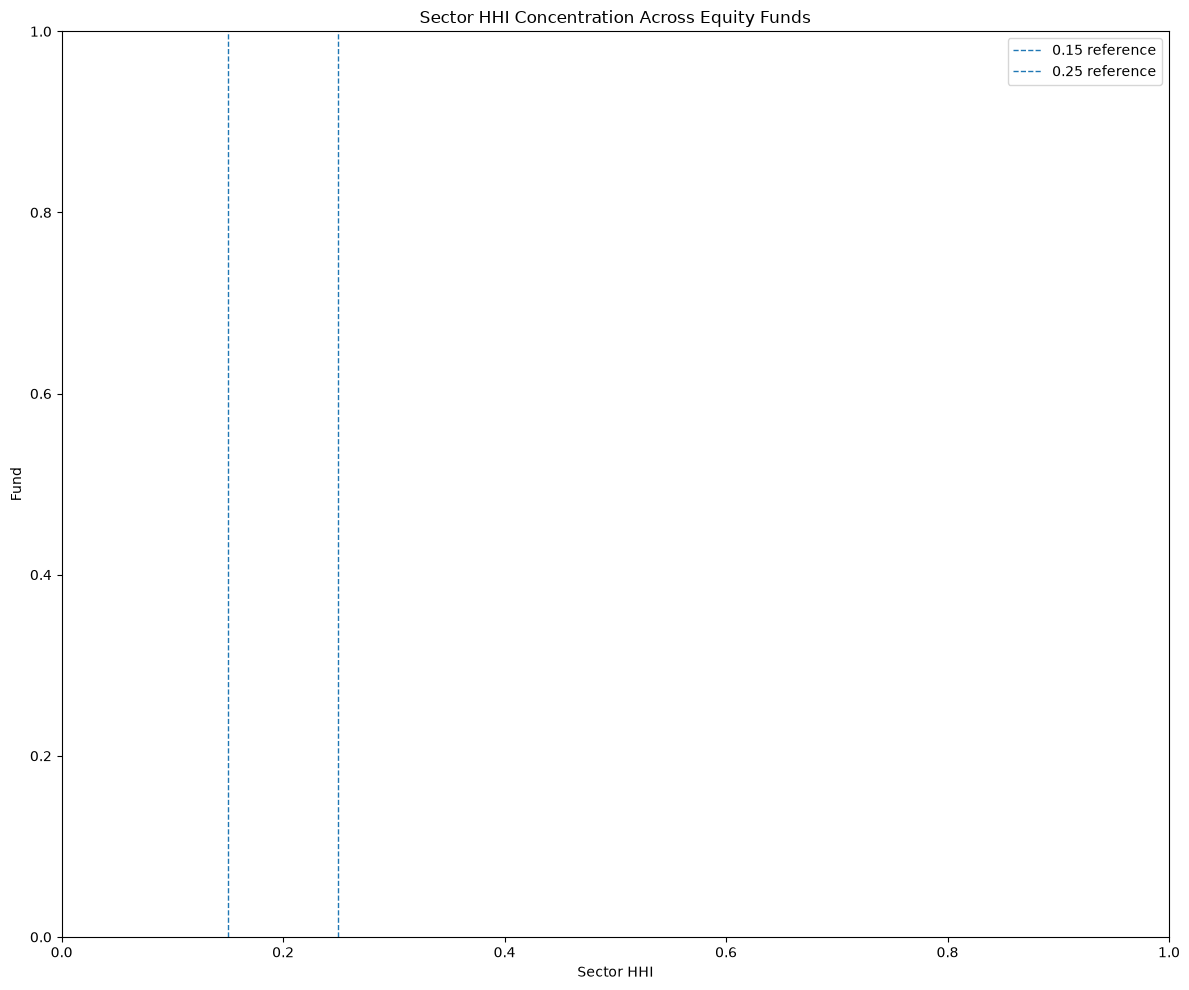

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = equity_hhi.sort_values(
    'sector_hhi',
    ascending=True
)

plt.figure(figsize=(12, 10))

sns.barplot(
    data=plot_data,
    x='sector_hhi',
    y='scheme_name'
)

plt.axvline(
    0.15,
    linestyle='--',
    linewidth=1,
    label='0.15 reference'
)

plt.axvline(
    0.25,
    linestyle='--',
    linewidth=1,
    label='0.25 reference'
)

plt.title(
    'Sector HHI Concentration Across Equity Funds'
)

plt.xlabel('Sector HHI')
plt.ylabel('Fund')
plt.legend()

plt.tight_layout()

plt.show()

In [177]:
plt.savefig(
    "C:/MutualFundProject/data/processed/Advanced_Analytics_CSV_file/reports/sector_hhi_equity_funds.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>